# 1. Vectors

In linear algebra, a _vector_ is and ordered list of number. Two important characteristics from vectors are:

* _Dimensionality_ $N$: The number of numbers in the vector, e.g., vector $x \in \mathbb{R}^N$
* _Orientation_: Wheter the vector is in _column orientation_ or _row orientation_

$$
    x = \begin{bmatrix} 1 \\ 4 \\ 5 \\ 6 \end{bmatrix}, \quad
    y = \begin{bmatrix} 0.3 \\ -7 \end{bmatrix}, \quad
    z = \begin{bmatrix} 1 & 4 & 5 & 6 \end{bmatrix}
$$

where, $x \in \mathbb{R}^4$ column vector, $y \in \mathbb{R}^2$ column vector, $z \in \mathbb{R}^4$ row vector. In some Python operations the orientation matters.

In Python, the _dimensionality_ of a vector or matrix is the number of geometric dimensions used to print out a numerical object. For example, all the above vectors are two-dimensional arrays, regardless of the number of elements contained in the vectors. Also, a list of numbers without a particular orientation is considered a 1D array in Python, regardless of the number of elements. Then, in Python the mathematical dimensionality is called the _length_ or the _shape_ of the vector.

Linear algebra convention is to assume that vectors are in column orientation unless otherwise specified. Row vectors are written as $w^T$, where $^T$ indicates the _transpose operation_.


## 1A. Creating and visualizing vectors in NumPy

In [1]:
import numpy as np

asList  = [1, 2, 3]
asArray = np.array([1, 2, 3])       # 1D array
rowVec  = np.array([[1, 2, 3]])     # row 
colVec  = np.array([[1], [2], [3]]) # column

In [2]:
print(f'asList: {np.shape(asList)}')
print(f'asArray: {asArray.shape}')
print(f'rowVec: {rowVec.shape}')
print(f'colVec: {colVec.shape}')

asList: (3,)
asArray: (3,)
rowVec: (1, 3)
colVec: (3, 1)


The output shows that the 1D array asArray is of size (3), whereas the orientation-endowd vectors are 2D arrays and stored as size (1,3) or (3, 1) depending on the orientation.

### 1A1. Geometry of vectors

The geometric interpretation of a vecotr is a straight line with a specific length, also called _magnitude_, and direction, also called _angle_ (computed relative to the positive _x_-axis). The two points of a vector are called the tail (start) and the head (end).

## 1B. Operations on vectors

### 1B1. Adding two vectors

To add two vectors, simply add each corresponding element. Vector addition is defined only for two vectors that have the same dimensionality.

$$
    \begin{bmatrix} 4 \\ 5 \\ 6 \end{bmatrix} + \quad
    \begin{bmatrix} 10 \\ 20 \\ 30 \end{bmatrix} = \quad
    \begin{bmatrix} 14 \\ 25 \\ 36 \end{bmatrix}
$$

In [3]:
v = np.array([4 ,5 ,6])
w = np.array([10, 20, 30])
u = np.array([0, 3, 6, 9])

vPlusW = v + w
print(vPlusW)

# uPlusW = u + w # This will lead to an error

[14 25 36]


In the next example, a row and a column vector are added but Python implemented an operation called broadcasting which is not defined in linear algebra.

In [4]:
v = np.array([[4, 5, 6]])       # row vector
w = np.array([[10, 20, 30]]).T  # column vector

v + w

array([[14, 15, 16],
       [24, 25, 26],
       [34, 35, 36]])

### 1B2. Substracting two vectors

Vector substraction is the opposite of vector addition, which is defined only for two vectors that have the same dimensionality.

$$
    \begin{bmatrix} 4 \\ 5 \\ 6 \end{bmatrix} - \quad
    \begin{bmatrix} 10 \\ 20 \\ 30 \end{bmatrix} = \quad
    \begin{bmatrix} -6 \\ -15 \\ -24 \end{bmatrix}
$$

### 1B3. Geometry of vector addition and substraction

To add two vectors geometrically, place the vectors such that the tail of one vector is at the head of the other vector; the summed vector traverses from the tail fo the first vector to the head of the second.

To substract two vectors geometrically, line up the two vectors such that their tails are at the same coordinate; the difference vector is the line that goes from the geat of the "negative" vector to the head of the "positive" one. __Vector substraction__ is the basis for orthogonal vector decomposition, which in turn is the basis for linear least squares.

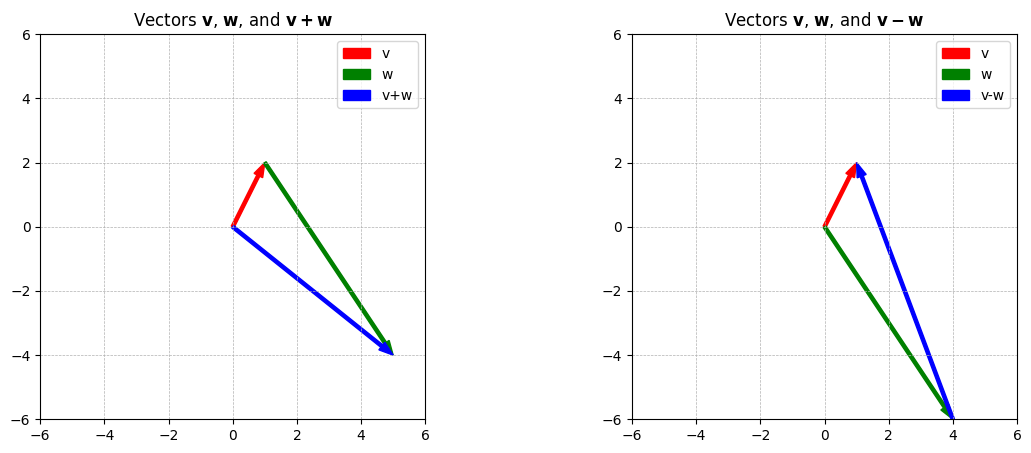

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# vectors
v = np.array([1, 2])
w = np.array([4, -6])
vPlusW = v + w
vMinusW = v - w

# plot
fig1, axs = plt.subplots(1, 2, figsize=(14,5))

# plot vectors
# v + w
axs[0].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='r', length_includes_head=True, label='v')
axs[0].arrow(v[0], v[1], w[0], w[1], head_width=0.3, width=0.1, color='g', length_includes_head=True, label='w')
axs[0].arrow(0 , 0, vPlusW[0], vPlusW[1], head_width=0.3, width=0.1, color='b', length_includes_head=True, label='v+w')

# plot style
axs[0].grid(linestyle='--', linewidth=0.5)
axs[0].axis('square')
axs[0].axis([-6, 6, -6, 6])
axs[0].legend()
axs[0].set_title(r'Vectors $\mathbf{{v}}$, $\mathbf{{w}}$, and $\mathbf{{v+w}}$')

# v - w
axs[1].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='r', length_includes_head=True, label='v')
axs[1].arrow(0, 0, w[0], w[1], head_width=0.3, width=0.1, color='g', length_includes_head=True, label='w')
axs[1].arrow(w[0], w[1], vMinusW[0], vMinusW[1], head_width=0.3, width=0.1, color='b', length_includes_head=True, label='v-w')

# plot style
axs[1].grid(linestyle='--', linewidth=0.5)
axs[1].axis('square')
axs[1].axis([-6, 6, -6, 6])
axs[1].legend()
axs[1].set_title(r'Vectors $\mathbf{{v}}$, $\mathbf{{w}}$, and $\mathbf{{v-w}}$')

fig1.savefig('Figure_02_02.png', dpi=300)
plt.show()

### 1B4. Vector-scalara multiplication

A _scalar_ in linear algebra is a number on its own. Typically, scaralrs are indicated using lowercase Greek letters such as $\mu$ or $\lambda$. Then, scalar multiplication is indicated as, for example, $\lambda \mathbf{v}$.

Vector-scalar multiplication is done by multiplying each vector element by the scalar.

$$
    \lambda = 4, \; \mathbf{w} = \begin{bmatrix} 9 \\ 4 \\ 1 \end{bmatrix}, \quad
    \lambda \mathbf{w} = \begin{bmatrix} 36 \\ 16 \\ 4 \end{bmatrix}
$$

A vector of all zeros is called the _zero vector_ $\mathbf{0}$. Using this type of vector to solve problems is often called the _trivial solution_ and is excluded.

In [ ]:
s = 2           # int type; float type will give an error when a * s
a = [3, 4, 5]
b = np.array(a)

print(a * s)  # a is interpreted as a list and any scalar times a list gives the same list repeated scalar times
print(a * b)

[3, 4, 5, 3, 4, 5]
[ 9 16 25]


### 1B5. Scalar-vector addition

Adding a scalar to a vector is not formally defined in linear algebra. Nevertheless, in Python the scalar-vector addition is comparable to scalar-vector multiplication: the scalar is added to each vector element.


In [50]:
s = 2
v = np.array([3, 6])

print(s + v)

[5 8]


#### 1B5A. The geometry of vector-scalar multiplication

Scalars __scale__ vectors without changing their direction. There are four effects of vector-scalar multiplication that depend on wheter the scalar is greater than 1, between 0 and 1, exactly 0, or negative

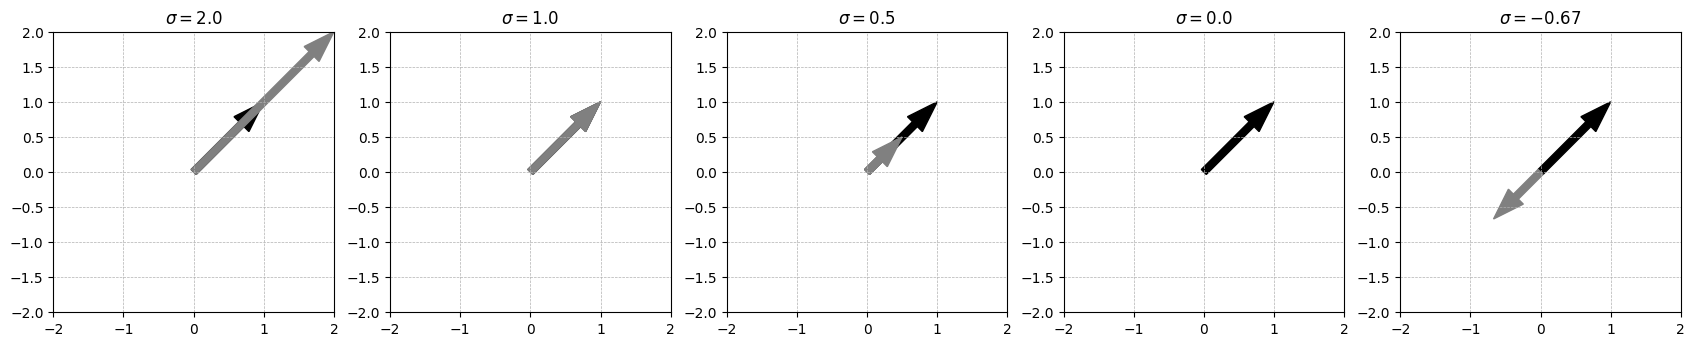

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# vectors
v = np.array([1, 1])
sigma = [2.0, 1.0, 0.5, 0.0, -0.67]
# plot
fig1, axs = plt.subplots(1, 5, figsize=(21,5))

# plot vectors
for i,s in enumerate(sigma):
    sigmaV = s * v
    axs[i].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='k', length_includes_head=True)
    if s != 0:
        axs[i].arrow(0, 0, sigmaV[0], sigmaV[1], head_width=0.3, width=0.1, color='grey', length_includes_head=True)

    # plot style
    axs[i].grid(linestyle='--', linewidth=0.5)
    axs[i].axis('square')
    axs[i].axis([-2, 2, -2, 2])
    axs[i].set_title(rf'$\sigma={s}$')

fig1.savefig('Figure_02_03.png', dpi=300)
plt.show()

Vectors are elements that are pointing along an infinitely long line that passess through the origin and goes to infinity in both directions. Even, if a scalar is negative, the "rotated" vector still points aloong the same infinite line and thus the negative scalar does not change the direction.

### 1B6. Transpose

A matrix has rows and columns; therefore, each matrix elements has a (_row,column_) index. The transpose operation swaps those indices.

$$
    \mathbf{m}_{i,j}^T = \mathbf{m}_{j,i}
$$

Vectors have either one row or one column, depending on their orientation. Then, swapping the _i,j_ indices swaps the rows and columns.

Transposing twice returns the vector to its original orientation.

$$
    \mathbf{v}^{TT} = \mathbf{v}
$$

### 1B7. Vector broadcasting in Python

Broadcasting means to repeat an operation multiple times between one vector and each element of another vector. 

In [ ]:
v = np.array([[1, 2, 3]]).T   # col vector
w = np.array([[10 ,20]])      # row vector
print(v + w)                  # addition with broadcasting

[[11 21]
 [12 22]
 [13 23]]


## 1C. Vector magnitude and unit vectors

The _magnitude_ of a vector, also called the _geometric length_ or the _norm_, is the distance from the tail to head of a vector, and is computed using the standard Euclidean distance formula: the square root of the sum of the squared vector elements.
$$
    \|\mathbf{v}\| = \sqrt{\sum_{i=1}^n \mathit{v}_i^2}
$$

In [62]:
v = np.array([1, 2, 3, 7, 8, 9])
v_dim = len(v)              # math dimensionality
v_mag = np.linalg.norm(v)   # math magnitude, lenght, or norm

print(v_dim)
print(v_mag)

6
14.422205101855956


There are some applications where a vector that has a geometric length of one, which is called a _unit vecotr_, is wanted. Example aapplications include orthogonal matrices, rotation matrices, eigenvectors, and singular vectors.

There is an infinite number of unit vecotrs and _nonunit vectors_, although the set of infinite nonunit vecotrs is larger than the set of infinite unit vectors. However, any nonunit vector has an associated unit vector.

$$
    \hat{\mathbf{v}} = \frac{1}{\| \mathbf{v}\|} \mathbf{v}
$$

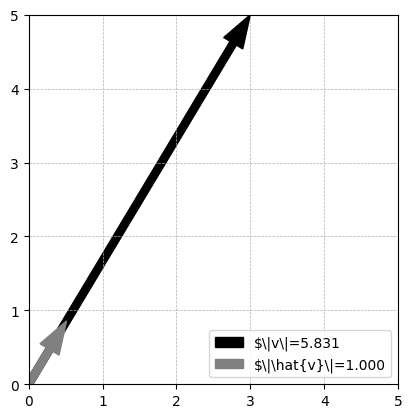

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# vectors
v = np.array([3, 5])
v_mag = np.linalg.norm(v)
v_hat = 1 / v_mag * v
v_hat_mag = np.linalg.norm(v_hat)

# plot
# plot vectors
plt.arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='k', length_includes_head=True, label=rf'$\|v\|={v_mag:.3f}')
plt.arrow(0, 0, v_hat[0], v_hat[1], head_width=0.3, width=0.1, color='grey', length_includes_head=True, label=rf'$\|\hat{{v}}\|={v_hat_mag:.3f}')

# plot style
plt.grid(linestyle='--', linewidth=0.5)
plt.axis('square')
plt.axis([0, 5, 0, 5])
plt.legend()


plt.savefig('Figure_02_04.png', dpi=300)
plt.show()

## 1D. The vector dot product

The _dot product_, also called _inner product_ ($\mathbf{u}^T\mathbf{v}$, $\mathbf{u}\cdot\mathbf{v}$, or $\langle \mathbf{u}, \mathbf{v} \rangle$), is a single number that provides information about the relantionship between two vectors. To do the dot product perform an element-wise multiplication and sum. i.e., it is only valid between two vectors of the same dimensionality.

$$
    \delta = \sum_{i=1}^n a_i b_i
$$

The dot product measures the _similarity_ or _mapping_ between two vectors. 

In [69]:
v = np.array([1, 2, 3, 4])
w = np.array([5, 6, 7, 8])

np.dot(v,w)

np.int64(70)

Scalar multiplying one vector scales the dot prodcut by the same amount.
$$
    \sigma \mathbf{v}^T\mathbf{w}
$$

In [70]:
s = 10

np.dot(s * v,w)

np.int64(700)

### 1D1. The dot product is distributive

The distributive property of mathematics is that $a(b+c) = ab + ac$. Then, in vectors and the vector dot product, it means that the dot prodcut of a vector sum equals the sum of the vector dot products.
$$
    \mathbf{a}^T(\mathbf{b} + \mathbf{c}) = \mathbf{a}^T\mathbf{b} + \mathbf{a}^T\mathbf{c}
$$

* __Orthogonal vectors have a zero dot product__

In [ ]:
a = np.array([0, 1, 2])
b = np.array([3, 5, 8])
c = np.array([13, 21, 34])

res1 = np.dot(a, b+c)
res2 = np.dot(a,b) + np.dot(a,c)

print(res1,res2)

110 110


### 1D2. Geometry of the dot product

It is the product of the magnitudes of the two vecotrs, scaled by the cosine of the angle between them. This means, that the sign of the dot product is determined entirely by the geometric relationship between the two vectors.
$$
    \alpha = \cos \left(\theta_{\mathbf{v},\mathbf{w}} \right)\|\mathbf{v}\|\|\mathbf{w}\|
$$.


<function matplotlib.pyplot.show(close=None, block=None)>

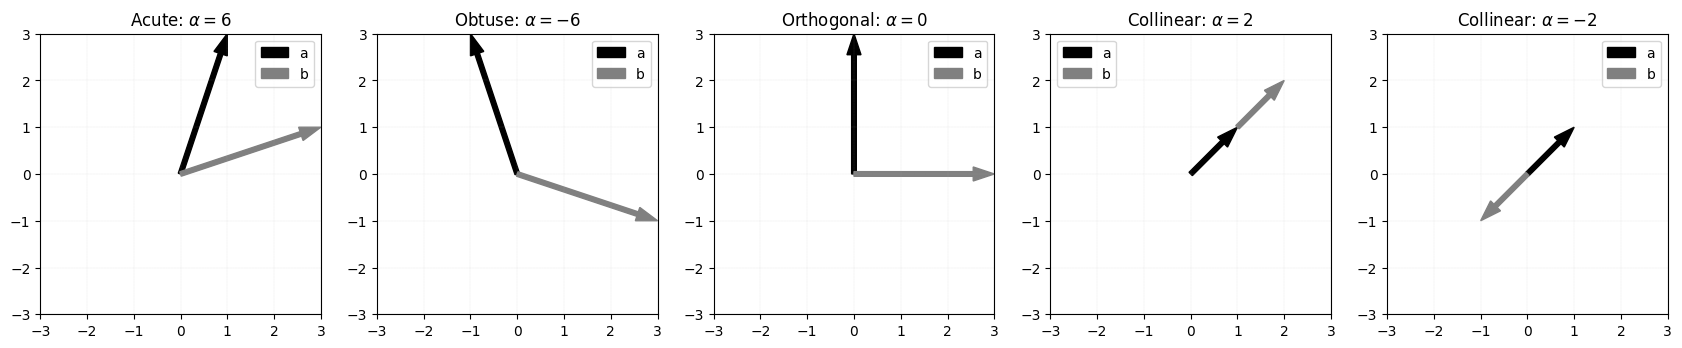

In [81]:
fig1, axs = plt.subplots(1, 5, figsize=(21, 5))

# Acute
v = np.array([1, 3])
w = np.array([3,1])
vAcuW = np.dot(v, w)
axs[0].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='k', length_includes_head=True, label='a')
axs[0].arrow(0, 0, w[0], w[1], head_width=0.3, width=0.1, color='grey', length_includes_head=True, label='b')
axs[0].grid(linestyle='--', linewidth=0.1)
axs[0].axis('square')
axs[0].axis([-3, 3, -3, 3])
axs[0].legend()
axs[0].set_title(rf'Acute: $\alpha={vAcuW}$')

# Obtuse
v = np.array([-1, 3])
w = np.array([3, -1])
vObtW = np.dot(v, w)
axs[1].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='k', length_includes_head=True, label='a')
axs[1].arrow(0, 0, w[0], w[1], head_width=0.3, width=0.1, color='grey', length_includes_head=True, label='b')
axs[1].grid(linestyle='--', linewidth=0.1)
axs[1].axis('square')
axs[1].axis([-3, 3, -3, 3])
axs[1].legend()
axs[1].set_title(rf'Obtuse: $\alpha={vObtW}$')

# Orthogonal 
v = np.array([0, 3])
w = np.array([3, 0])
vOrtW = np.dot(v, w)
axs[2].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='k', length_includes_head=True, label='a')
axs[2].arrow(0, 0, w[0], w[1], head_width=0.3, width=0.1, color='grey', length_includes_head=True, label='b')
axs[2].grid(linestyle='--', linewidth=0.1)
axs[2].axis('square')
axs[2].axis([-3, 3, -3, 3])
axs[2].legend()
axs[2].set_title(rf'Orthogonal: $\alpha={vOrtW}$')

# Collinear 0°
v = np.array([1, 1])
w = np.array([1, 1]) # starts at v
vCol0W = np.dot(v, w)
axs[3].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='k', length_includes_head=True, label='a')
axs[3].arrow(v[0], v[1], w[0], w[1], head_width=0.3, width=0.1, color='grey', length_includes_head=True, label='b')
axs[3].grid(linestyle='--', linewidth=0.1)
axs[3].axis('square')
axs[3].axis([-3, 3, -3, 3])
axs[3].legend()
axs[3].set_title(rf'Collinear: $\alpha={vCol0W}$')

# Collinear 180°
v = np.array([1, 1])
w = np.array([-1, -1])
vCol180W = np.dot(v, w)
axs[4].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='k', length_includes_head=True, label='a')
axs[4].arrow(0, 0, w[0], w[1], head_width=0.3, width=0.1, color='grey', length_includes_head=True, label='b')
axs[4].grid(linestyle='--', linewidth=0.1)
axs[4].axis('square')
axs[4].axis([-3, 3, -3, 3])
axs[4].legend()
axs[4].set_title(rf'Collinear: $\alpha={vCol180W}$')

fig1.savefig('Figure_02_05.png', dpi=300)
plt.show

## 1E. Other vector multiplications

### 1E1. Hadamard multiplication

It is an element-wise multiplication, i.e., each corresponding element in the two vectors is multiplied. The product is a vector of the same dimensionality as the two multiplicands.

Hadamard multiplication is a convenient way to organize multiple scalar multiplications. 

In [82]:
a = np.array([5, 4, 8 ,2])
b = np.array([1, 0, 0.5, 3])

a * b

array([5., 0., 4., 6.])

### 1E2. Outer product

It is a way to create a matrix from a column vector and a row vector. Each row in the outer product matrix is the row vector scalar multiplied by the corresponding element in the column vector. Then, each vector in an outer product can have different dimensionalities.
$$
    \mathbf{v}\mathbf{w}^T
$$

$$
    \begin{bmatrix} a \\ b \\ c \end{bmatrix} \begin{bmatrix} d & e \end{bmatrix} = \begin{bmatrix} ad & ae \\ bd & be \\ cd & ce \end{bmatrix}
$$

## 1F. Orthogonal vector decomposition

To "decompose" a vector or matrix means to break up that matrix into multiple simpler pieces. It reveals information that is "hidden" in a matrix, to make the matrix easier to work with, or for data compression. For example, 42.01 can be decomposed as 42 and 0.01, where in computation 42 requires less memory as being an integer than 0.01 that is a floating-point number. Also, 42 can be decomposed as the product of prime numbers 2, 3, and 7 (_prime factorization_).

In the next example and orthogonal vector c to b is gotten from a, i.e., the target vector $\mathbf{t}$ needs to be perpendicular $\perp$ to the reference vector $\mathbf{r}$, $\mathbf{t}_{\perp_{\mathbf{r}}}$. The opposite is the parallel component, indicated as $\mathbf{t}_{\parallel_{\mathbf{r}}}$.

The parallel component is given by
$$
    \mathbf{t}_{\parallel_{\mathbf{r}}} = \mathbf{r} \frac{\mathbf{t}^T\mathbf{r}}{\mathbf{r}^T\mathbf{r}}
$$

The perpendicular component is expressed as
$$
    \mathbf{t} = \mathbf{r}, \mathbf{t}_{\perp_{\mathbf{r}}} + \mathbf{t}_{\parallel_{\mathbf{r}}}
$$
$$
    \mathbf{t}_{\perp_{\mathbf{r}}} = \mathbf{t} - \mathbf{t}_{\parallel_{\mathbf{r}}}
$$

[ 2.05882353 -1.23529412]


<function matplotlib.pyplot.show(close=None, block=None)>

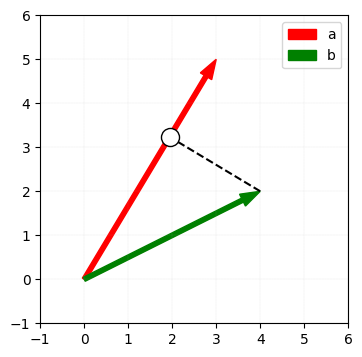

In [ ]:
a = np.array([3, 5])
b = np.array([4, 2])
# \langle a , c \rangle = 0
# c = b - \beta a
# a.T c = a.T(b - \beta a) = 0
# a.T b = a.T \beta a
# \beta = (a.T b)/ a.T a 
beta = np.dot(a, b) / np.dot(a, a)
shrinkedA = beta * a
c = b - shrinkedA
c_mag = np.linalg.norm(c)
print(c)

# draw the figure
plt.figure(figsize=(4,4))

# vectors
plt.arrow(0, 0, a[0], a[1], color='r', head_width=0.3, width=0.1, length_includes_head=True, label='a')
plt.arrow(0, 0, b[0], b[1], color='g', head_width=0.3, width=0.1, length_includes_head=True, label='b')

# projection vector
plt.plot([b[0],shrinkedA[0]],[b[1],shrinkedA[1]],'k--')

# projection on a
plt.plot(beta*a[0], beta*a[1], 'ko', markerfacecolor='w', markersize=13)

# plt.arrow(c[0], c[1], b[0], b[1], color='b', linestyle='--', label=r'($b - \beta a$)')
plt.grid(linestyle='--', linewidth=0.1)
plt.axis('square')
plt.axis([-1, 6, -1, 6])
plt.legend()
plt.show

## 1G. Excercises

### 1G1. Figure 2-2

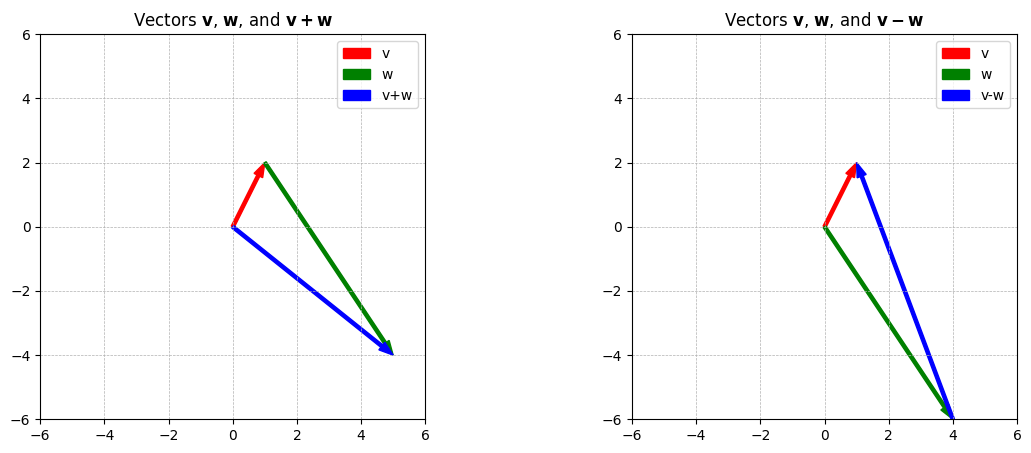

In [103]:
import matplotlib.pyplot as plt
import numpy as np

# vectors
v = np.array([1, 2])
w = np.array([4, -6])
vPlusW = v + w
vMinusW = v - w

# plot
fig1, axs = plt.subplots(1, 2, figsize=(14,5))

# plot vectors
# v + w
axs[0].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='r', length_includes_head=True, label='v')
axs[0].arrow(v[0], v[1], w[0], w[1], head_width=0.3, width=0.1, color='g', length_includes_head=True, label='w')
axs[0].arrow(0 , 0, vPlusW[0], vPlusW[1], head_width=0.3, width=0.1, color='b', length_includes_head=True, label='v+w')

# plot style
axs[0].grid(linestyle='--', linewidth=0.5)
axs[0].axis('square')
axs[0].axis([-6, 6, -6, 6])
axs[0].legend()
axs[0].set_title(r'Vectors $\mathbf{{v}}$, $\mathbf{{w}}$, and $\mathbf{{v+w}}$')

# v - w
axs[1].arrow(0, 0, v[0], v[1], head_width=0.3, width=0.1, color='r', length_includes_head=True, label='v')
axs[1].arrow(0, 0, w[0], w[1], head_width=0.3, width=0.1, color='g', length_includes_head=True, label='w')
axs[1].arrow(w[0], w[1], vMinusW[0], vMinusW[1], head_width=0.3, width=0.1, color='b', length_includes_head=True, label='v-w')

# plot style
axs[1].grid(linestyle='--', linewidth=0.5)
axs[1].axis('square')
axs[1].axis([-6, 6, -6, 6])
axs[1].legend()
axs[1].set_title(r'Vectors $\mathbf{{v}}$, $\mathbf{{w}}$, and $\mathbf{{v-w}}$')

fig1.savefig('Figure_02_02.png', dpi=300)
plt.show()

### 1G2. The norm of a vector

In [112]:
v = np.random.randint(100, size=np.random.randint(10))
if len(v)>0:
    sum_squared_v = 0
    for idx, numb in enumerate(v):
        sum_squared_v += numb**2
    the_norm = np.sqrt(sum_squared_v)
    print(the_norm, np.linalg.norm(v))

173.72967507020786 173.72967507020786


### 1G3. Unit vector generator

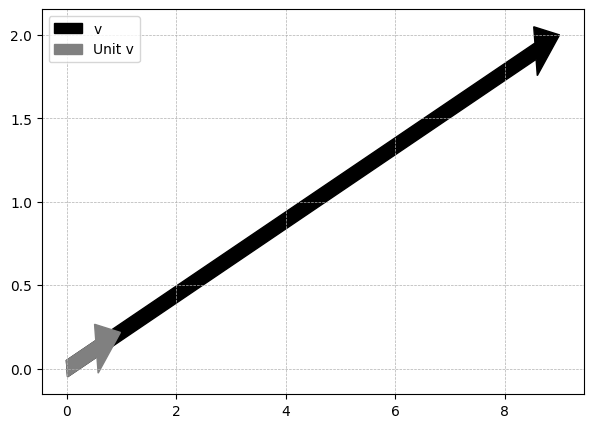

In [122]:
v = np.array([np.random.randint(-10, 10),np.random.randint(-10, 10)])
if v[0] != 0 and v[1] != 0:
    v_mag = np.linalg.norm(v)
    v_unit = 1 / v_mag * v

    plt.figure(figsize=(7,5))

    plt.arrow(0, 0, v[0], v[1], color='k', head_width=0.3, width=0.1, length_includes_head=True, label='v')
    plt.arrow(0, 0, v_unit[0], v_unit[1], color='gray', head_width=0.3, width=0.1, length_includes_head=True, label='Unit v')
    plt.grid(linestyle='--', linewidth=0.5)
    plt.legend()
    plt.show
    plt.savefig('Exercise_02_03.png', dpi=300)

### 1G4. Scaling the unit vector

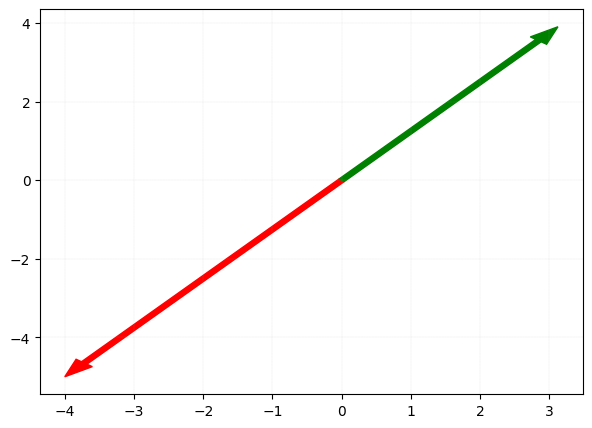

In [125]:
v = np.array([np.random.randint(-5, 5), np.random.randint(-5,5)])
scale = np.random.randint(-5,5)
if v[0] != 0 and v[1] != 0:
    v_unit = 1 / np.linalg.norm(v) * v
    w = scale * v_unit
    
    plt.figure(figsize=(7,5))
    
    plt.arrow(0, 0, v[0], v[1], color='r', head_width=0.3, width=0.1, length_includes_head=True)
    plt.arrow(0, 0, w[0], w[1], color='g', head_width=0.3, width=0.1, length_includes_head=True)
    
    plt.grid(linestyle='--', linewidth=0.1)
    plt.legend
    plt.show
    plt.savefig('Exercise_02_04.png', dpi=300)

### 1G5. Transpose

In [159]:
v = np.random.randint(100, size=np.random.randint(1, 10))
v_T = np.zeros((1, len(v)))
if len(v) > 0:
    for idx, numb in enumerate(v):
        v_T[0, idx] = numb
        
    print(v)
    print(v_T)
print(v.shape, v_T.shape)
type(v)

[20 60]
[[20. 60.]]
(2,) (1, 2)


numpy.ndarray

### 1G6. Dot product of a.T a = ||a||^2

In [165]:
v = np.random.randint(100, size=np.random.randint(100))
squared_v_mag = np.linalg.norm(v) ** 2
vDotV = np.dot(v, v)

print(squared_v_mag,vDotV)

328640.0 328640


### 1G7. Dot product commutative property

In [167]:
vector_size=np.random.randint(100)
v = np.random.randint(100, size=vector_size)
w = np.random.randint(100, size=vector_size)
vTw = 0
wTv = 0

for idx, v_numb in enumerate(v):
    vTw += v_numb * w[idx]
    wTv += w[idx] * v_numb
    
print(vTw, wTv, np.dot(v,w), np.dot(w,v))

103208 103208 103208 103208


### 1G8. Orthogonal vector decomposition

[ 2.05882353 -1.23529412]


<function matplotlib.pyplot.show(close=None, block=None)>

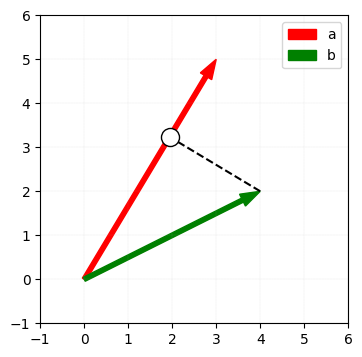

In [168]:
a = np.array([3, 5])
b = np.array([4, 2])
# \langle a , c \rangle = 0
# c = b - \beta a
# a.T c = a.T(b - \beta a) = 0
# a.T b = a.T \beta a
# \beta = (a.T b)/ a.T a 
beta = np.dot(a, b) / np.dot(a, a)
shrinkedA = beta * a
c = b - shrinkedA
c_mag = np.linalg.norm(c)
print(c)

# draw the figure
plt.figure(figsize=(4,4))

# vectors
plt.arrow(0, 0, a[0], a[1], color='r', head_width=0.3, width=0.1, length_includes_head=True, label='a')
plt.arrow(0, 0, b[0], b[1], color='g', head_width=0.3, width=0.1, length_includes_head=True, label='b')

# projection vector
plt.plot([b[0],shrinkedA[0]],[b[1],shrinkedA[1]],'k--')

# projection on a
plt.plot(beta*a[0], beta*a[1], 'ko', markerfacecolor='w', markersize=13)

# plt.arrow(c[0], c[1], b[0], b[1], color='b', linestyle='--', label=r'($b - \beta a$)')
plt.grid(linestyle='--', linewidth=0.1)
plt.axis('square')
plt.axis([-1, 6, -1, 6])
plt.legend()
plt.show

### 1G9. Target and reference vector

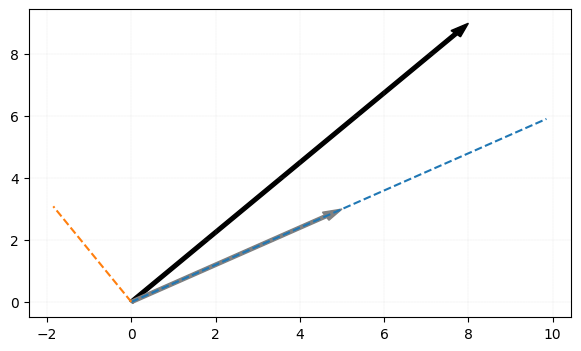

In [175]:
def orthogonal_decomposition(t, r):
    parallel = r * np.dot(t, r) / np.dot(r, r)
    perpendicular = t - parallel
    return parallel, perpendicular

t = np.random.randint(10, size=2)
r = np.random.randint(10, size=2)
t_par_r, t_perp_r = orthogonal_decomposition(t, r)

plt.figure(figsize=(7,4))

plt.arrow(0, 0, t[0], t[1], color='k', head_width=0.3, width=0.1, length_includes_head=True, label='t')
plt.arrow(0, 0, r[0], r[1], color='gray', head_width=0.3, width=0.1, length_includes_head=True, label='r')

plt.plot([0, t_par_r[0]], [0, t_par_r[1]], linestyle='--', label='t_par_r')
plt.plot([0, t_perp_r[0]], [0, t_perp_r[1]], linestyle='--', label='t_perp_r')

plt.grid(linestyle='--', linewidth=0.1)
plt.legend
plt.show
plt.savefig('Exercise_02_09.png', dpi=300)

### 1G10. Sanity checking on orthogonal decomposition

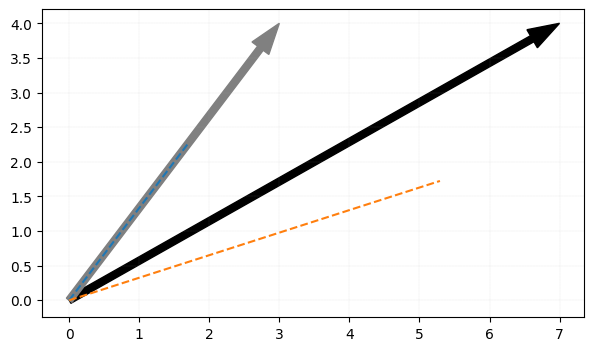

In [177]:
def orthogonal_decomposition(t, r):
    parallel = r * np.dot(t, r) / np.dot(t, t) # must be in the denominator r.T r
    perpendicular = t - parallel
    return parallel, perpendicular

t = np.random.randint(10, size=2)
r = np.random.randint(10, size=2)
t_par_r, t_perp_r = orthogonal_decomposition(t, r)

plt.figure(figsize=(7,4))

plt.arrow(0, 0, t[0], t[1], color='k', head_width=0.3, width=0.1, length_includes_head=True, label='t')
plt.arrow(0, 0, r[0], r[1], color='gray', head_width=0.3, width=0.1, length_includes_head=True, label='r')

plt.plot([0, t_par_r[0]], [0, t_par_r[1]], linestyle='--', label='t_par_r')
plt.plot([0, t_perp_r[0]], [0, t_perp_r[1]], linestyle='--', label='t_perp_r')

plt.grid(linestyle='--', linewidth=0.1)
plt.legend
plt.show
plt.savefig('Exercise_02_10.png', dpi=300)